# L1 Norm and Compressive sensing
In this notebook, you'll see the power of using "sparsity constraints" when fitting data, either recovering signals hidden under extreme levels of noise or from severely undersampled signals<br>
You will do this using "ISTA", a model where in every iteration you just add the gradient of the fidelity term and then you soft threshold the signal in a base where you assume that the signal will be sparse. <br>
Mathematically, the problem is <br><br> $ \arg \min_x \lVert Ax -y \rVert^2 + \beta \lVert x  \rVert_1$ <br><br> 
Note that with $A$ here we can mean any matrix, including those that represent the composition of multiple transformations. <br>
This will actively look for an $x$ vector which has as many $0$ elements as possible

<br> You will see that this allow recovering signals under high levels of noise and also when you undersample it strongly. <br>
For ISTA, the algorithm is pretty simple, as follows:
* Set $x^0,\,\beta,\,\tau$ with $\tau$ the step size ("learning rate") and $\beta$ the regularitzation strenght. Then iterate as follows:
* $g \leftarrow A^T(Ax -y)$
* $x^{*} \leftarrow x^{k} - \tau g$
* $x^{k+1} \leftarrow sign(x^{*})\,\max\{0,\lvert x^{*} \rvert - \beta\tau \}$ (A.K.A. soft thresholding)


Basically:
* Add to $x^k$ a small amount of the gradient of the data fidelity term $A^T(Ax^k-y)$.
* Cut to zero all the components of $x$ that are smaller than $\beta\tau$.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Task 1: 1D example
Let's show this with a 1D example. In here we will generate a 1D sine wave over multiple periods, corrupt it with extremely high levels of noise, try to recover it by imposing that its Fourier transform is sparse.<br>
Indeed if you have 2,000 samples, its FT will have 2,000 frequencies. If you know that less than a dozen of them are non-zero, you can provide a really strong constraint!

In [42]:
# Create a signal that's the sum of 3 frequencies. 
# Then add a noise which is much stronger than the signal 
# (e.g.: if the signal is between -1 and 1, add a standard deviation of 1 between each sample)

xv = np.arange(0,5,0.01)
yv = .6*np.sin(10*xv)+0.4*np.sin(55*xv)+1.*np.sin(40*xv)
yvn = yv.copy()+np.random.normal(0,.8,yv.shape)

Text(0.5, 1.0, 'A snippet of the signal vs the noise')

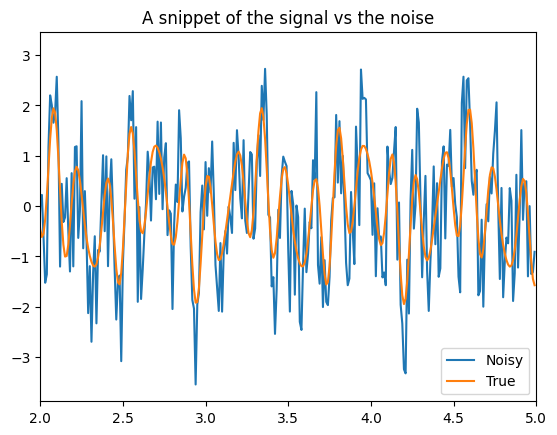

In [43]:

plt.plot(xv,yvn)
plt.plot(xv,yv)
plt.xlim(2,5)
plt.legend(('Noisy','True'))
plt.title('A snippet of the signal vs the noise')

Text(0.5, 1.0, 'The FT of the signals')

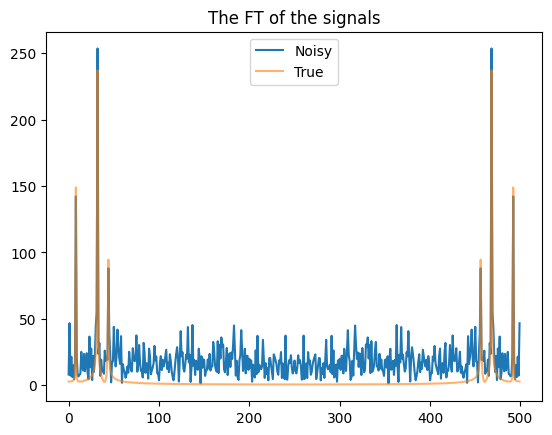

In [44]:
plt.plot(np.abs(np.fft.fft(yvn)))
plt.plot(np.abs(np.fft.fft(yv)),alpha=.6)
plt.legend(('Noisy','True'))
plt.title('The FT of the signals')
# plt.xlim(0,200)


In this case $A$ is the inverse fourier transform $\mathcal{F}^{-1}$. We assume that our signal is _sparse_ in the domain of the Fourier transform. Our previous problem becomes:<br>
$\arg\min_x \lVert y - \mathcal{F}^{-1}(x) \rVert_2^2 + \beta \lVert x \rVert_1$<br>
**Note**: here you are optimizing for $x$, which is in "frequency" space. To get your denoised signal in "signal" space you need to take the inverse fourier transform of the solution $x$.<br>
ISTA here becomes:<br>
* $g\leftarrow \mathcal{F} \left[\mathcal{F}^{-1}x-y\right]$ ($g$ is a frequency)
* $x^*\leftarrow x^k - \tau g$
* $x^{k+1}\leftarrow sign(x^*) \max\left\{ \lvert x^*\rvert - \tau \beta,0\right\}$


## Task 1.1: 1D example - undersampling
Take the same "true" signal. Invent a random subsampling procedure where you keep only some of the points. Try to recover the whole signal

In this case $A$ is the inverse fourier transform $M\mathcal{F}^{-1}$, with $M$ the "masking" matrix that represent the subsampling operations (i.e.: 1 for the pixels we have read, 0 otherwise). We assume that our signal is _sparse_ in the domain of the Fourier transform. Our previous problem becomes:<br>
$\arg\min_x \lVert M\left[ y - \mathcal{F}^{-1}(x)\right] \rVert_2^2 + \beta \lVert x \rVert_1$<br>
**Note**: here you are optimizing for $x$, which is in "frequency" space. To get your denoised signal in "signal" space you need to take the inverse fourier transform of the solution $x$.<br>
ISTA here becomes:<br>
* $g\leftarrow \mathcal{F} \left[M \mathcal{F}^{-1}x-y\right]$ ($g$ is a frequency)
* $x^*\leftarrow x^k - \tau g$
* $x^{k+1}\leftarrow sign(x^*) \max\left\{ \lvert x^*\rvert - \tau \beta,0\right\}$